# Préparation des données

Deux jeux tabulaires à variables continues : California Housing (régression) et MAGIC Gamma Telescope (classification).

Étapes : chargement, nettoyage, inspection, figures, découpage train / val / test, sauvegarde.

Sorties : `data/processed/{jeu}_{train,val,test}.csv` et les figures dans `figures/`.

In [36]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing, fetch_openml
from sklearn.model_selection import train_test_split

os.makedirs("data/processed", exist_ok=True)
os.makedirs("figures", exist_ok=True)

## 1. Chargement

Même format pour les deux jeux : les variables explicatives, puis une colonne `target`.

In [37]:
cal = fetch_california_housing(as_frame=True).frame
cal = cal.rename(columns={"MedHouseVal": "target"})
cal.shape

(20640, 9)

In [38]:
X, y = fetch_openml(data_id=1120, as_frame=True, return_X_y=True, parser="auto")
X.columns = X.columns.str.rstrip(":")
magic = X.astype(float).assign(target=(y == "h").astype(int))   # h (hadron) = 1, g (gamma) = 0
magic.shape

(19020, 11)

## 2. Nettoyage

On cherche les valeurs manquantes et les doublons. Un doublon pourrait se retrouver à la fois dans le train et dans le test.

In [39]:
for name, df in [("california", cal), ("magic", magic)]:
    print(name, df.shape, "| NaN :", df.isna().sum().sum(), "| doublons :", df.duplicated().sum())

california (20640, 9) | NaN : 0 | doublons : 0
magic (19020, 11) | NaN : 0 | doublons : 115


In [40]:
cal = cal.drop_duplicates().reset_index(drop=True)
magic = magic.drop_duplicates().reset_index(drop=True)

## 3. Inspection

### California

In [41]:
cal.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [42]:
cal.describe().T

,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
target,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


Deux colonnes sont plafonnées à la collecte : `HouseAge` à 52 (« 52 ans ou plus ») et `target` à 5.00001 (« 500 k$ ou plus »). Part des lignes au plafond :

In [43]:
(cal["HouseAge"] == cal["HouseAge"].max()).mean(), (cal["target"] == cal["target"].max()).mean()

(np.float64(0.06167635658914729), np.float64(0.04675387596899225))

### MAGIC

In [44]:
magic.describe().T

,count,mean,std,min,25%,50%,75%,max
fLength,18905.0,53.161416,42.259789,4.2835,24.3597,37.1295,69.9754,334.1770
fWidth,18905.0,22.145872,18.300664,0.0000,11.8742,17.1438,24.7124,256.3820
fSize,18905.0,2.824643,0.472377,1.9413,2.4771,2.7400,3.1011,5.3233
fConc,18905.0,0.380247,0.182709,0.0131,0.2358,0.3540,0.5035,0.8930
fConc1,18905.0,0.214560,0.110384,0.0003,0.1285,0.1964,0.2850,0.6752
fAsym,18905.0,-4.177867,59.010059,-457.9161,-20.4791,4.0629,24.1335,575.2407
fM3Long,18905.0,10.618826,50.900687,-331.7800,-12.7693,15.3380,35.8694,238.3210
fM3Trans,18905.0,0.259364,20.775268,-205.8947,-10.8358,0.7500,10.9489,179.8510
fAlpha,18905.0,27.551644,26.083055,0.0000,5.5164,17.5330,45.7040,90.0000
fDist,18905.0,193.712554,74.685712,1.2826,142.2690,191.8320,240.4090,495.5610


In [45]:
magic["target"].value_counts(normalize=True)

target
0    0.652314
1    0.347686
Name: proportion, dtype: float64

## 4. Visualisation

### California

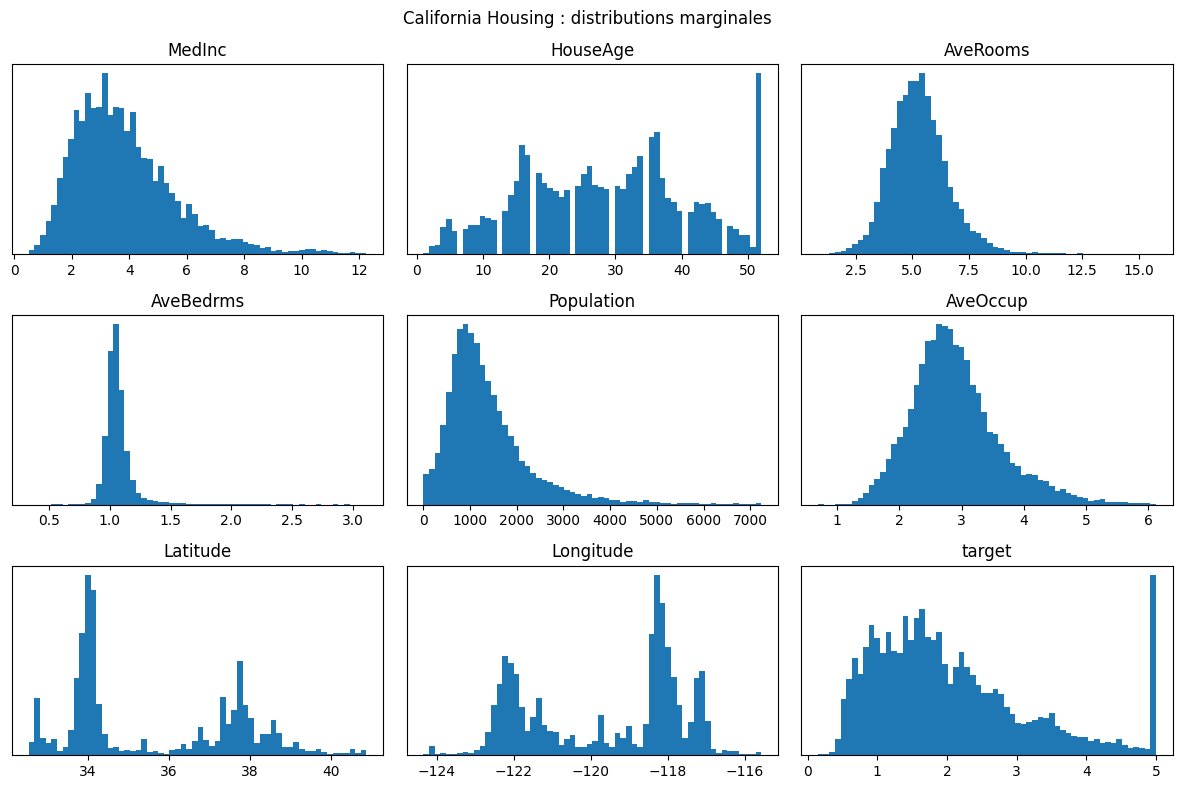

In [46]:
# axe x coupé au 99,5e centile à cause des queues lourdes (les plafonds restent visibles)
fig, axes = plt.subplots(3, 3, figsize=(12, 8))
for ax, c in zip(axes.flat, cal.columns):
    ax.hist(cal[c], bins=60, range=(cal[c].min(), cal[c].quantile(0.995)))
    ax.set_title(c)
    ax.set_yticks([])
fig.suptitle("California Housing : distributions marginales")
fig.tight_layout()
fig.savefig("figures/california_marginales.png", dpi=150, bbox_inches="tight")

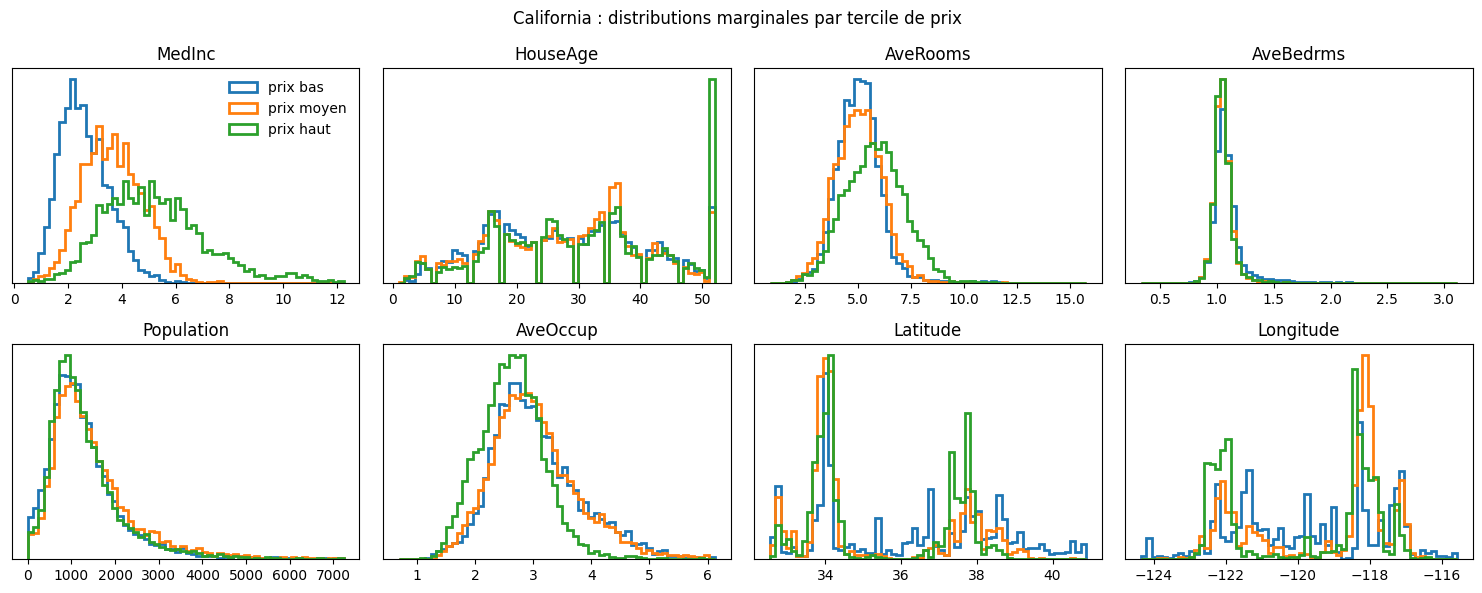

In [47]:
# mêmes histogrammes, séparés en trois niveaux de prix
feats_cal = cal.columns.drop("target")
prix = pd.qcut(cal["target"], 3, labels=["prix bas", "prix moyen", "prix haut"])
fig, axes = plt.subplots(2, 4, figsize=(15, 6))
for ax, c in zip(axes.flat, feats_cal):
    bornes = (cal[c].min(), cal[c].quantile(0.995))   # coupe les queues extrêmes (AveOccup, Population)
    for g in prix.cat.categories:
        ax.hist(cal.loc[prix == g, c], bins=60, range=bornes, density=True,
                histtype="step", linewidth=2, label=g)
    ax.set_title(c)
    ax.set_yticks([])
axes.flat[0].legend(frameon=False)
fig.suptitle("California : distributions marginales par tercile de prix")
fig.tight_layout()
fig.savefig("figures/california_marginales_par_prix.png", dpi=150, bbox_inches="tight")

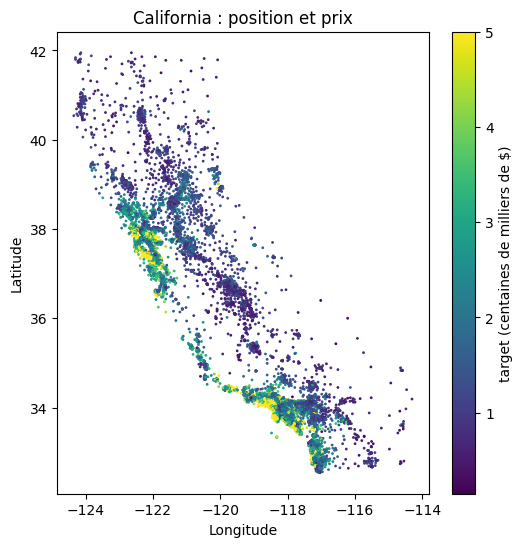

In [48]:
# la carte servira de référence pour juger les données générées
fig, ax = plt.subplots(figsize=(6, 6))
sc = ax.scatter(cal["Longitude"], cal["Latitude"], c=cal["target"], s=1, cmap="viridis")
fig.colorbar(sc, ax=ax, label="target (centaines de milliers de $)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("California : position et prix")
fig.savefig("figures/california_carte.png", dpi=150, bbox_inches="tight")

### MAGIC

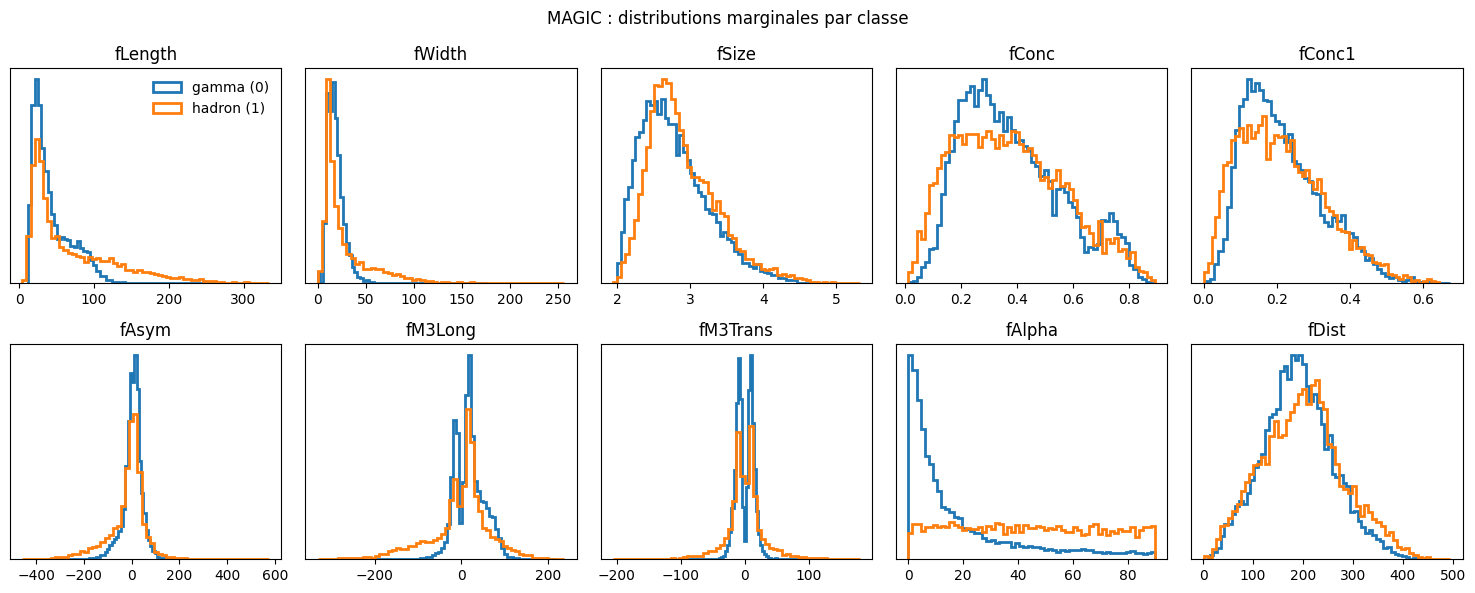

In [49]:
# densités par classe, pour comparer malgré le déséquilibre 65 / 35
feats = magic.columns.drop("target")
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for ax, c in zip(axes.flat, feats):
    for cls, label in [(0, "gamma (0)"), (1, "hadron (1)")]:
        ax.hist(magic.loc[magic["target"] == cls, c], bins=60, density=True,
                histtype="step", linewidth=2, label=label)
    ax.set_title(c)
    ax.set_yticks([])
axes.flat[0].legend(frameon=False)
fig.suptitle("MAGIC : distributions marginales par classe")
fig.tight_layout()
fig.savefig("figures/magic_marginales.png", dpi=150, bbox_inches="tight")

### Corrélations

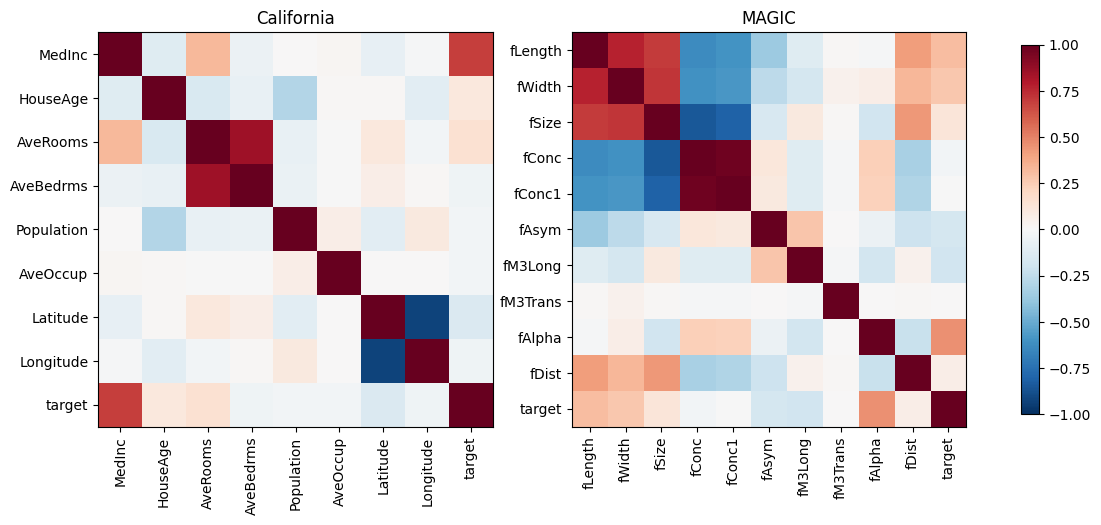

In [50]:
# Corrélations (Pearson)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (name, df) in zip(axes, [("California", cal), ("MAGIC", magic)]):
    corr = df.corr()
    im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_xticks(range(len(corr)), corr.columns, rotation=90)
    ax.set_yticks(range(len(corr)), corr.columns)
    ax.set_title(name)
fig.colorbar(im, ax=axes, shrink=0.8)
fig.savefig("figures/correlations.png", dpi=150, bbox_inches="tight")

## 5. Découpage train / val / test (70 / 15 / 15)

Le découpage est stratifié sur la classe (MAGIC) ou sur les déciles de `target` (California), pour que les trois parties aient la même distribution de la cible.

In [51]:
splits = {}
for name, df in [("california", cal), ("magic", magic)]:
    strat = df["target"] if name == "magic" else pd.qcut(df["target"], 10, labels=False)
    train, reste = train_test_split(df, train_size=0.70, stratify=strat, random_state=0)
    val, test = train_test_split(reste, test_size=0.50, stratify=strat[reste.index], random_state=0)
    splits[name] = (train, val, test)
    print(name, len(train), len(val), len(test),
          "| moyenne target :", round(train["target"].mean(), 3), round(val["target"].mean(), 3), round(test["target"].mean(), 3))

california 14447 3096 3097 | moyenne target : 2.07 2.064 2.067
magic 13233 2836 2836 | moyenne target : 0.348 0.348 0.348


## 6. Sauvegarde

In [52]:
cal.to_csv("data/california.csv", index=False)
magic.to_csv("data/magic.csv", index=False)

for name, (train, val, test) in splits.items():
    for split, part in [("train", train), ("val", val), ("test", test)]:
        part.to_csv(f"data/processed/{name}_{split}.csv", index=False)

sorted(os.listdir("data/processed"))

['california_test.csv',
 'california_train.csv',
 'california_val.csv',
 'magic_test.csv',
 'magic_train.csv',
 'magic_val.csv']